KULA.BHZ.KO


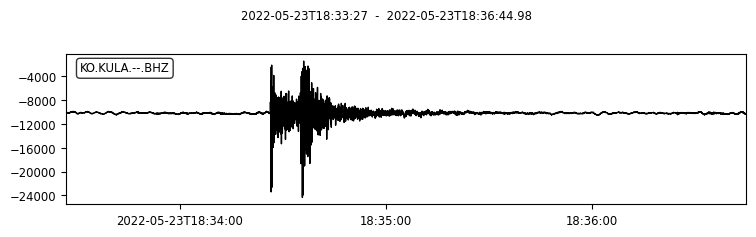

SIMA.BHZ.KO


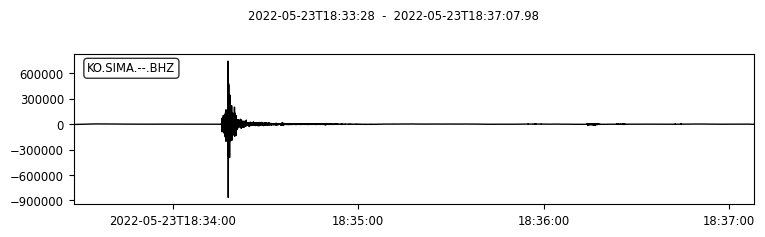

BAKL.BHZ.KO


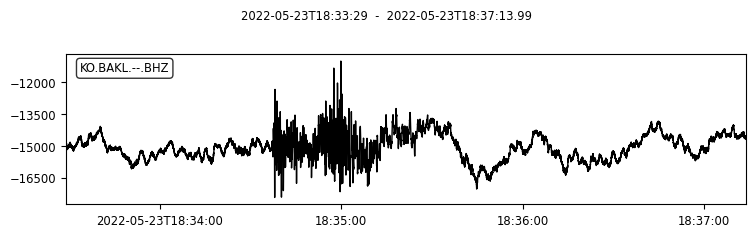

TVSB.BHZ.KO


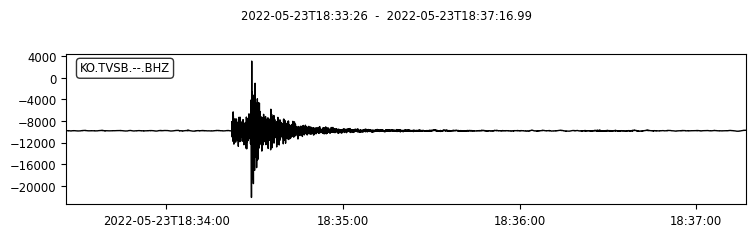

BABD.BHZ.KO


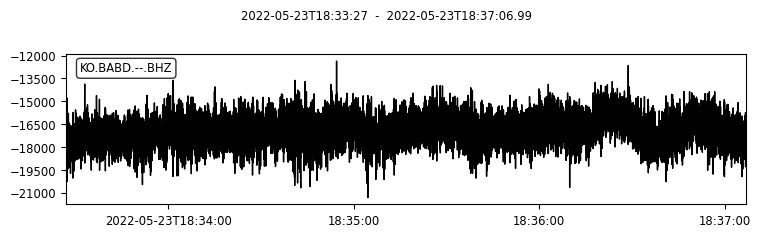

SHUT.BHZ.KO


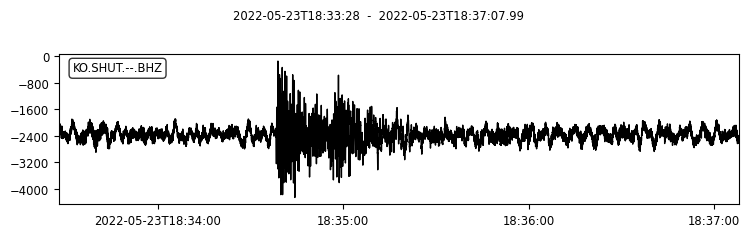

In [1]:
import os
from obspy.core import read
from obspy.signal.trigger import classic_sta_lta
from obspy.signal.trigger import plot_trigger
from obspy.signal.trigger import z_detect
from obspy.signal.trigger import recursive_sta_lta
import shutil

os.makedirs("class1")
os.makedirs("class2")
os.makedirs("class3")

dir_path = '.'
date = "07_05_22"

for file_name in os.listdir(dir_path):

    if os.path.isfile(os.path.join(dir_path, file_name)) and os.path.join(dir_path, file_name).format().__contains__("BHZ"):
        print(file_name)
        
        stream = read(os.path.join(dir_path, file_name))
        trace = stream[0]
        trace.plot()

        # get integer input
        a = int(input("Enter 1 2"))
        if a == 1:
            shutil.copy2(file_name, './class1/' + date + file_name.replace('KO', 'SAC'))
        elif a == 2:
            shutil.copy2(file_name, './class2/' + date + file_name.replace('KO', 'SAC'))
        else:
            shutil.copy2(file_name, './class3/' + date + file_name.replace('KO', 'SAC'))

        # df = trace.stats.sampling_rate
        # cft = recursive_sta_lta(trace.data, int(5 * df), int(10 * df))
        # plot_trigger(trace, cft, 1.2, 0.5)

        # with open(os.path.join(save_path, file_name.replace(".KO", ".txt")), 'w') as f:
        #     for nth,data in enumerate(trace.data):
        #         f.write(str(data))
        #         if(nth+1 != len(trace.data)):
        #             f.write(' ')


In [1]:
import os
from obspy.core import read
from obspy.signal.trigger import classic_sta_lta
from obspy.signal.trigger import plot_trigger
from obspy.signal.trigger import z_detect
from obspy.signal.trigger import recursive_sta_lta
import shutil

dir_path = '.'
date = "07_05_22"

for file_name in os.listdir(dir_path):

    if os.path.isfile(os.path.join(dir_path, file_name)) and os.path.join(dir_path, file_name).format().endswith("BHZ.KO"):
        print(file_name)
        shutil.copy2(file_name, '../../data/' + date + file_name.replace('KO', 'SAC'))
        

/usr/lib/python3/dist-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 1.1build1 is an invalid version and will not be supported in a future release
  warnings.warn(
/usr/lib/python3/dist-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.43ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(


SIMA.BHZ.KO
KULA.BHZ.KO
BABD.BHZ.KO
BAKL.BHZ.KO
TVSB.BHZ.KO
SHUT.BHZ.KO


/home/maintain/.local/lib/python3.10/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (100.0) of bandpass is at or above Nyquist (50.0). Applying a high-pass instead.
  warnings.warn(msg)


KO.GEDZ.--.BHZ | 2022-02-10T12:28:58.000000Z - 2022-02-10T12:33:12.990000Z | 100.0 Hz, 25500 samples


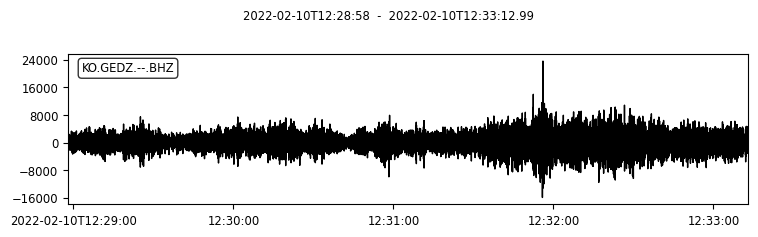

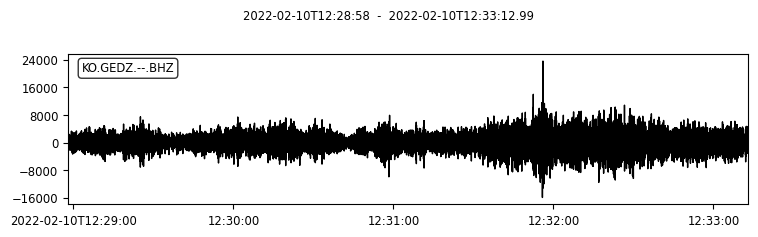

In [9]:
# Import the clean_sac_file function from the previous example
from obspy import read, Trace, Stream
from obspy.signal.filter import bandpass

def clean_sac_file(input_file, output_file, freq_min, freq_max):
    """
    Applies a bandpass filter to a SAC file to clean noise.

    Inputs:
    - input_file: path to the input SAC file
    - output_file: path to the output SAC file
    - freq_min: minimum frequency of the passband in Hz
    - freq_max: maximum frequency of the passband in Hz
    """
    # Read in the SAC file as an ObsPy Trace object
    trace = read(input_file)[0]

    # Apply a bandpass filter to the trace
    trace_filtered = trace.copy()
    trace_filtered.data = bandpass(trace.data, freqmin=freq_min, freqmax=freq_max, df=trace.stats.sampling_rate)

    # Write the filtered trace to a new SAC file
    trace_filtered.write(output_file, format='SAC')

# Test the clean_sac_file function on an example SAC file
input_file = "./GEDZ.BHZ.KO"
output_file = "example_filtered2.sac"
freq_min = 10.0
freq_max = 100.0
clean_sac_file(input_file, output_file, freq_min, freq_max)

# Verify that the filtered SAC file was created
trace_filtered = read(output_file)[0]
print(trace_filtered)


clean_sac_file = read(output_file)
clean_sac_file.plot()